# Mini EDA: Sales Data Analysis
This notebook performs a simple exploratory data analysis (EDA) of daily sales.  
We load the dataset, inspect its structure, calculate descriptive statistics, and visualize trends (plot).

## 1. Loading the data

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/sales_data.csv")
df

,day,sales
0,1,10
1,2,12
2,3,9
3,4,23
4,5,14
5,6,18
6,7,20
7,8,17
8,9,22
9,10,19


## 2. Data overview
- **day** — sequential day number  
- **sales** — number of units sold 

## 3. Descriptive Statistics
To understand the distribution of sales, we calculate key statistical metrics:

- **Minimum** — lowest sales value  
- **Maximum** — highest sales value  
- **Mean** — average daily sales  
- **Median** — central value, robust to outliers  
- **Standard deviation** — how much sales vary day to day  
- **Quartiles (Q1, Q2, Q3)** — distribution spread

In [2]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
day,10.0,5.5,3.027650,1.0,3.25,5.5,7.75,10.0
sales,10.0,16.4,4.926121,9.0,12.50,17.5,19.75,23.0


### Interpretation
- The median is close to the mean, indicating a fairly symmetric distribution.  
- The standard deviation shows moderate variability in daily sales.  
- Q1 and Q3 indicate that 50% of all sales fall within the interquartile range.

## 4. Sales Trend Visualization

The line plot below shows how sales change over time.  
This helps identify trends, peaks, and periods of stability.

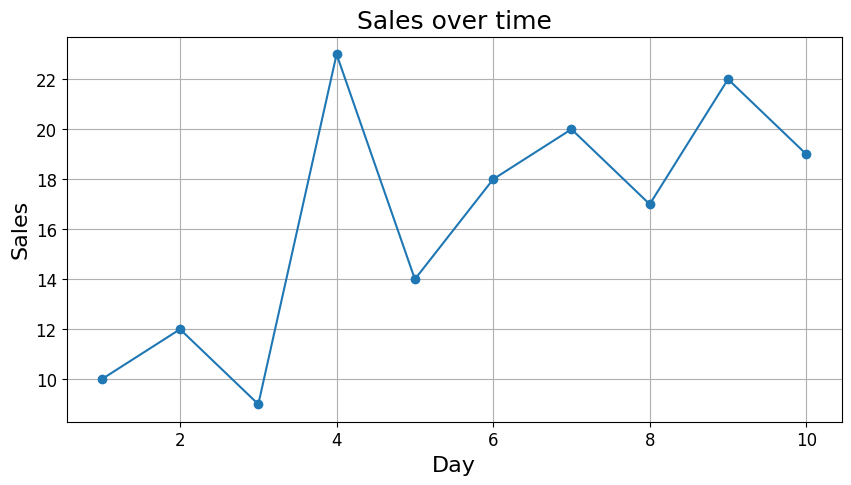

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(df["day"], df["sales"], marker="o")
plt.xlabel("Day", fontsize=16)
plt.ylabel("Sales", fontsize=16)
plt.title("Sales over time", fontsize=18)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True)
plt.savefig("../images/sales_plot.png", dpi=300, bbox_inches="tight")
plt.show()



### Interpretation

- The general trend appears increasing.  
- There are noticeable peaks around the higher days.  
- No extreme outliers are present.

## Histogram

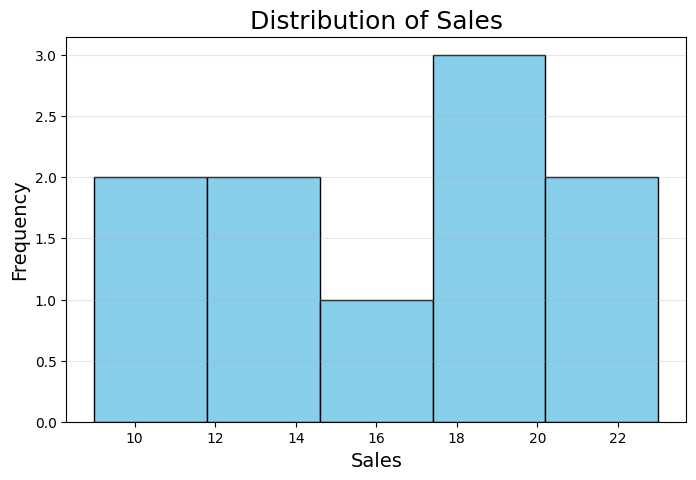

In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df["sales"], bins=5, color="skyblue", edgecolor="black")

##plt.axvline(df["sales"].mean(), color="red", linestyle="--", label="Mean")
##plt.axvline(df["sales"].median(), color="green", linestyle="--", label="Median")


plt.title("Distribution of Sales", fontsize=18)
plt.xlabel("Sales", fontsize=14)
plt.ylabel("Frequency", fontsize=14)

plt.grid(axis="y", alpha=0.3)

plt.savefig("../images/sales_histogram.png", dpi=300, bbox_inches="tight")

plt.show()


## Moving everage

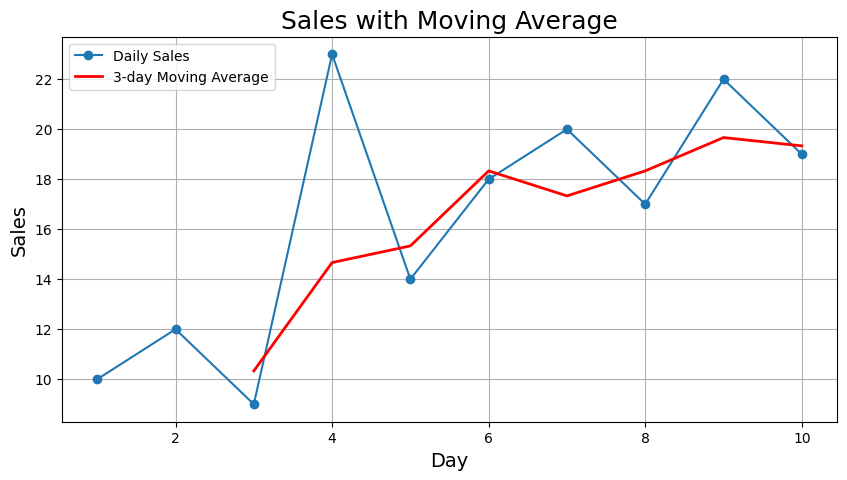

In [17]:
plt.figure(figsize=(10, 5))

plt.plot(df["day"], df["sales"], marker="o", label="Daily Sales")

df["moving_avg"] = df["sales"].rolling(window=3).mean()
plt.plot(df["day"], df["moving_avg"], color="red", linewidth=2, label="3-day Moving Average")

plt.title("Sales with Moving Average", fontsize=18)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Sales", fontsize=14)
plt.legend()
plt.grid(True)

plt.savefig("../images/sales_moving_average.png", dpi=300, bbox_inches="tight")

plt.show()

Moving Average smooths out daily fluctuations in sales and highlights the overall trend.
The chart shows that the moving average gradually increases from the initial values (around 10–12) to above 18–20 toward the end of the period.
This indicates a clear upward trend in sales, even though individual days may show minor variations.

## Linear regression

Predictions for the next day sales: 22.6


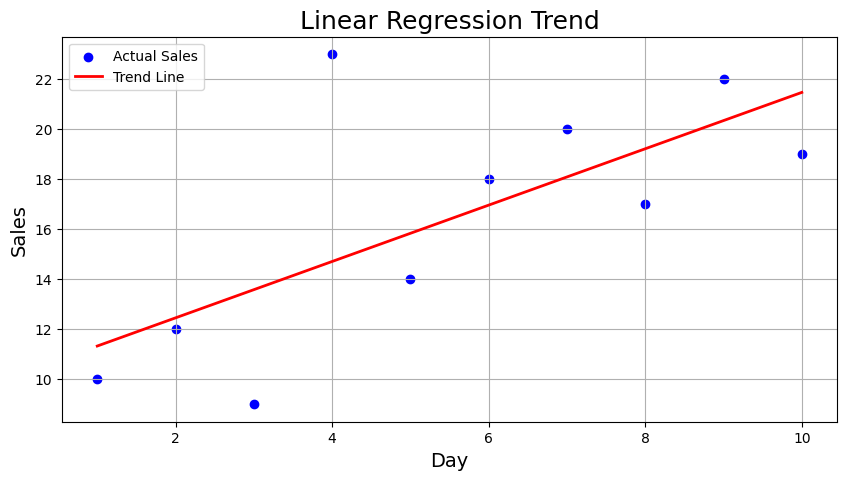

In [25]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt

# Data preparation
X = df["day"].values.reshape(-1, 1)
y = df["sales"].values

# Model
model = LinearRegression()
model.fit(X, y)

# Predictions for real points
y_pred = model.predict(X)

# Predictions for the next day
next_day = np.array([[df["day"].max() + 1]])
next_day_pred = model.predict(next_day)[0]

print("Predictions for the next day sales:", round(next_day_pred, 2))


plt.figure(figsize=(10, 5))
plt.scatter(df["day"], df["sales"], color="blue", label="Actual Sales")
plt.plot(df["day"], y_pred, color="red", linewidth=2, label="Trend Line")

plt.title("Linear Regression Trend", fontsize=18)
plt.xlabel("Day", fontsize=14)
plt.ylabel("Sales", fontsize=14)
plt.legend()
plt.grid(True)

plt.savefig("../images/sales_regression.png", dpi=300, bbox_inches="tight")
plt.show()

Linear Regression is used to model the relationship between time (day) and sales.
The fitted trend line shows a clear upward trajectory, indicating that sales tend to increase as days progress.
The model also allows us to generate a simple forecast: based on the existing pattern, the predicted sales for the next day continue this upward trend.
Even though the dataset is small, the regression line effectively highlights the overall positive direction of sales growth.

## 5. Conclusions

- Daily sales show moderate variability with a clear upward trend.  
- The distribution of sales is balanced, with no extreme outliers or anomalies.
- Linear regression confirms this positive trend and provides a simple forecast, indicating that sales are likely to continue rising.
- Overall, the dataset is clean, stable, and suitable for further analysis, forecasting, or segmentation.

This mini‑EDA demonstrates the basic workflow of data exploration using Python and Jupyter Notebook.